<a href="https://colab.research.google.com/github/JorgeEncinas/pytorch_ztm/blob/main/02_neural_network_classification_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Neural Network Classification with PyTorch
SHIFT + CMD + SPACE to read the docstring (just an important note before we start)

Classification is predicting whether something is one thing or another.

## Binary Classification.
  - Example: Spam or Not Spam

## Multi-Class Classification
Each target sample has one label; one class.

## Multi-Label Classification
Each target sample can have more than one label.

### Goals
- Architecture of a NN Classification Model
- Input shapes and output shapes of a Classification Model (features and labels)
- Creating custom data to view, fit on and predict on
- Steps in modelling
  - Creating a model
  - Setting a loss function
  - Setting an optimizer
  - Creating a Training Loop
  - Evaluating a Model
- Saving and Loading Models
- Harnessing the power of Non-Linearity
- Different Classification evaluation methods.

## Classification Inputs and Outputs

For photos, how do we numerically represent them?
Imagine our photos are resized to be 224*224, which is a common choice of size for Computer Vision models

Now this representation of an image would be (W: 224, H:224, C:3) where 'C' means the color channels: Red, Green, and Blue. Of course the specifics of the order of these three vary but let's not think about that too deeply.

- Input: Numerical encodings
- Output: Predictions; probabilities

We're gonna see this hands-on. The whole idea of ML is that adjustment of the algorithm and the data, you can improve your predictions.

For our user output, we don't want to display the probabilities, so the Actual Output must be the label that is most likely!

The actual tensor shape is `[batch_size, colour_channels, width, height]`

Color channels sometimes come first, or sometimes come at the end. It is easily re-shapeable.

## Architecture: Binary vs Multiclass

| Hyperparameter | Binary Classification | Multiclass Classification
| --- | --- | --- |
| Input Layer Shape (`in_features`) | Same as # of features | ~ |
| Hidden Layer(s) | Problem specific, min=1, max=unlimited | ~ |
| Neurons per hidden layer | Problem specific, generally [10, 512] | ~ |
| Output layer shape (`out_features`) | 1 (one class or the other) | 1 per class (e.g. 3 for food, person, or dog photo) |
| Hidden layer activation | Usually ReLU (but can vary) | ~ |
| Output Activation | Sigmoid (torch.sigmoid) | Softmax (torch.softmax) |
| Loss Function | Binary Crossentropy (torch.nn.BCELoss) | Cross entropy (torch.nn.CrossEntropyLoss) |
| Optimizer | SGD, Adam | ~ |

In [ ]:
# This is just an example, not meant to be run as code!
import torch
from torch import nn

model = nn.Sequential(
    nn.Linear(in_features=3, out_features=100),
    nn.Linear(in_features=100, out_features=100),
    nn.ReLU(),
    nn.Linear(in_features=100, out_features=3)
)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(
    params = model.parameters(),
    lr = 0.001
)

## 1. Make Classification data and get it ready

In [1]:
import sklearn

In [239]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(
    n_samples=n_samples,
    noise=0.03, #I put in 0.3 at first, but that was way too much
    random_state=42 #equivalent of setting a seed
)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(f"First 5 samples of X: \n {X[:5]}")
print(f"First 5 samples of y: \n {y[:5]}")

First 5 samples of X: 
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y: 
 [1 1 1 1 0]


In [5]:
X.shape, y.shape

((1000, 2), (1000,))

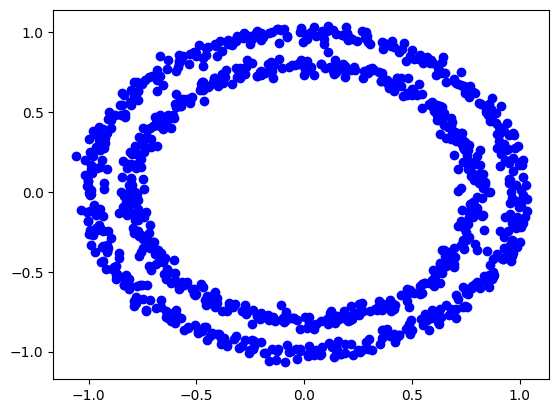

In [6]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c="b")

In [240]:
import pandas as pd

circles = pd.DataFrame({
    "X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})

circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


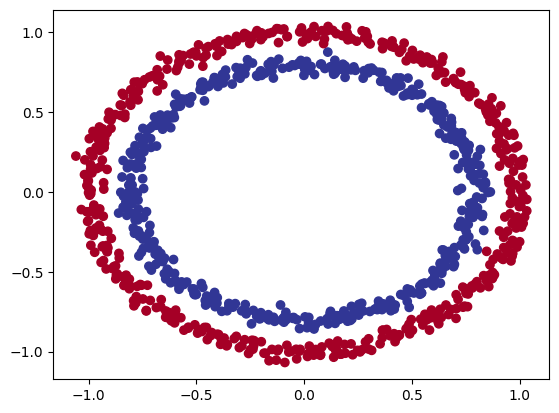

In [241]:
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap= plt.cm.RdYlBu #color map
)

The data we're working with is often referred to as a toy dataset:
- Small enough to experiment but sizeable enough to practice the fundamentals.

In this case, the fundamentals of NN Classification!

### 1.1 Check Input and Output Shapes

A very common error is that you may get your shapes wrong somewhere along the way.

In [9]:
X.shape, y.shape

((1000, 2), (1000,))

In [10]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes: {X_sample.shape}, {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes: (2,), ()


### 1.2 Turn data into tensors (from numpy). Create train and test splits

In [11]:
import torch
torch.__version__

'2.6.0+cu124'

In [12]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float) #default is float32 in pytorch, while it is float64 in numpy. This conversion will turn it into float32
y = torch.from_numpy(y).type(torch.float)

In [13]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [14]:
type(X), type(y), X.dtype, y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [15]:
torch.manual_seed(42)

In [243]:
# Let's randomly shuffle the data.
from sklearn.model_selection import train_test_split #Sci-kit Learn to the rescue again.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2 # 20% of the available data.
  )
X_train = torch.from_numpy(X_train).type(torch.float)
y_train = torch.from_numpy(y_train).type(torch.float)
X_test = torch.from_numpy(X_test).type(torch.float)
y_test = torch.from_numpy(y_test).type(torch.float)

In [75]:
len(X_train), len(y_train), len(X_test), len(y_test)

(800, 800, 200, 200)

In [18]:
n_samples

1000

## 3. Building a Model

Let's build a model to classify our blue and red dots.

The process:
1. Setup device-agnostic code so we can run on an Accelerator (GPU) if available
2. Construct a model (by subclassing `nn.Module`)
3. Define a loss function and optimizer
4. Create a Train and Test loop

In [20]:
# Import PyTorch and nn
import torch #We had imported this one but w/e
from torch import nn

In [21]:
device = 'cuda' if torch.cuda.is_available() else "cpu"
device

'cpu'

Now let's create a model that:
1. Subclasses `nn.Module`
2. Create 2 `nn.Linear` layers that are capable of handling the shapes of our data
3. Define a `forward()` method that outlines the Forward Pass (or the Forward Computation) of the model
4. Instantiate an instance of our model class and send it to the Target Device.

In [69]:
# 1. Constructing a model
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__() #Always goes, remember this!
    # 2. Create the 2 nn.Linear layers!
    # What's the input shape? 800 training samples of size 2 each. The input shape must be of 2, x and y
    #self.layer_1 = nn.Linear(
    #    in_features=2,
    #    out_features=5 # Choice architecture I guess. There is an upper limit where you start getting diminishing returns for upping the number on one given layer.
    #)
    #self.layer_2 = nn.Linear(
    #    in_features=5,
    #    out_features=1 #We're gonna treat this as the output layer.
    #)

    self.two_linear_layers = nn.Sequential(
        nn.Linear(in_features=2, out_features=5),
        nn.Linear(in_features=5, out_features=1)
    )

  # 3. Define forward() method
  def forward(self, x): #What does this even look like?
    #return self.layer_2(self.layer_1(x)) # Well, it simply consists of our layers applying their computations.
    return self.two_linear_layers.forward(x)

In [70]:
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (two_linear_layers): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [25]:
device

'cpu'

In [66]:
next(model_0.parameters()).device

device(type='cpu')

This class we made is what most of your NN building is going to look like.

In [36]:
# Let's replicate the model above using nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

This implements most of the code for us behind the scenes. The forward pass has been done for us.

So why not do this, instead of subclassing? Well, sometimes you want a more complex forward pass, which is why you might need it.

In [64]:
model_0.state_dict()

OrderedDict([('two_linear_layers.0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]])),
             ('two_linear_layers.0.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410])),
             ('two_linear_layers.1.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]])),
             ('two_linear_layers.1.bias', tensor([-0.2060]))])

In [76]:
# Make predictions
with torch.inference_mode():
  untrained_preds = model_0.forward(X_test.to(device))

In [77]:
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\n First 10 predictions: \n {untrained_preds[:10]}")
print(f"\n First 10 labels: \n {y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

 First 10 predictions: 
 tensor([[ 0.2025],
        [ 0.0233],
        [ 0.2210],
        [ 0.2532],
        [ 0.0360],
        [-0.0660],
        [-0.0498],
        [ 0.1024],
        [ 0.1977],
        [ 0.2920]])

 First 10 labels: 
 tensor([1., 1., 0., 1., 0., 0., 0., 0., 0., 0.])


### 2.1 Setup Loss Function and Optimizer

Which loss function and optimizer should you use?

This is problem-specific. For regression you may want MAE (Mean Absolute Error) or MSE (Mean Square Error)

For Classification you might want
  - Binary Cross Entropy
  - Cross Entropy

As a reminder, the Loss Function measures how wrong your model's predictions are.

For optimizers, 2 of the most common and useful are SGD and Adam, however PyTorch has many built-in options.

## Note: Logits layer

""The layer that feeds in to softmax (or other such normalization). The output of the softmax are the probabilities for the classification task, and its input is Logits Layer. The logits layer typically produces values from -infinity to +infinity and the softmax layer transforms it to values from 0 to 1"

## What will we use?

BCEWithLogitsLoss, which is Binary Cross Entropy.

For some common choices of loss functions and optimizers, check the book version of this course.

## Sidebar - Understanding BCE / Log Loss, by Daniel Godoy

From [this article by Daniel Godoy](https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a/)

Imagine some vector X with 10 values

X = [-2.2, -1.4, -0.8, 0.2, 0.4, 0.8, 1.2, 2.2, 2.9, 4.6]

Let's assign colors to them

Y = [r, r, gr, r, gr, gr, gr, gr, gr, gr] (red and green)

Our Binary Classification problem is: What is the probability of the point being green? Green points should have a probability of 1.0, while red ones have a probability of 0.0

That is:
  - Green = YES = 1.0
  - Red = NO = 0.0

If we were to fit a model to perform this classification, it will predict a probability of being green to each point. How can we evaluate how good (or bad) the predicted probabilities are?

That's what the Loss Function is for, and we expect it to return high values for bad predictions, and low values for good predictions.

For Binary Classification, the typical Loss Function is the **Binary Cross-Entropy / Log Loss**

## Binary Cross-Entrop / Log Loss

Here's the formula:

H(q) = -(1/N)*SUM( y_i * log( p(y_i) )) + (( 1 - y_i) * (log(1 - p(y_i))) )

y_i = the LABEL for one example, so you can imagine that:
  - if y_i = 1, then the first term is the one accounted for, and the second one cancels out since (1 - y_i) = (1 - 1)
  - if y_i = 0, then the second term is acounted for, and the first one cancels out, since (y_i = 0)

It will add either:
  - The log probability of YES (green): log( p(y) )
  - The log probability of NO (red): log( 1 - p(y) )

## Computing the loss - the visual way

It will be harder for me to talk about it here, given that there are some graphs here.

But what we do is we make a visual representation of the probabilities. The probabilities for the GREEN objects of being GREEN, which go from the bottom to the top,

AND the probabilities for the RED objects of being RED, which go from the top to the bottom. With these two different bars together, we can draw a sigmoid using the top of each bar.

Now with these probabilities, we can compute the BCE / Log Loss. We need to penalize bad predictions.

The (negative) log of the probability suits this purpose well: The log of values between 0 and 1 is always negative, so the negative log will return a positive value.

The actual reason we use log comes from the definition of CROSS-ENTROPY. For now, note that:
  - We need the loss to be zero when the probability associated with the true class is 1. That is, if Prob=1, then log(prob) = log(1) = 0
  - Conversely, we need it to be high when the probability associated with the true class is 0. That is, if Prob=0, then log(prob) = log(0.001) = -3 (which you can turn into a +3 bc we take the negative of the log)

So the log loss grows exponentially as p(x) is closer to 0. The actual log(0) is undefined though, so careful (My guess is that it rarely happens in practice).

Then the article takes the negative log of the probabilities, and those would be the Lossses of each and every point. then it averages them.

Mean = 0.3329, So the BCE / Log Loss is 0.3329

## What is Cross-Entropy?
Wouldn't you know it, what we pulled out of this hat is not the bunny, but the first handkerchief, tied to many many other handkerchiefs. So it is when learning.

This article links to [this other article](https://colah.github.io/posts/2015-09-Visual-Information/) For a deeper, more detailed look into entropy and cross-entropy and so on.

## Entropy
Entropy is a measure of the Uncertainty associated with a Given Distribution q(y).

If, imagine, all points on our case were one color, then we would not have any uncertainty, since you know all points are the same color. If you had half and half, randomly assigned, then entropy is log(2) (though they are not explaining why in this article)

Here is a formula for the cases in-between:

H(q) = - SUM_c_C( q(y_c) * log( q(y_c) ) )

What is this saying? Why multiply the value the distribution gives by its logarithm? I'm not sure.

If we know the true distribution, we can compute its entropy. If we don't know the true distribution (which must usually be the case), then we can try approximating the true distribution with another one, such as p(y) (Sounds familiar for all Laplace Approximation fans #LaplaceNation)

## Cross-Entropy

Assume our points follow this other distribution p(y). But we know they are actually coming from the TRUE, but UNKNOWN, distribution q(y).

If we compute Entropy like this, we are actually computing the CROSS-ENTROPY between both distributions

H_p(q) = - SUM_c_C( q(y_c) * log( p(y_c) ))

The difference is that you have log(p(y)) instead of log(q(y))

If we miraculously match p(y) to q(y) PERFECTLY, the computed values for Entropy and Cross-Entropy would match. But that's likely never happening.

Cross-Entropy, then, will have a BIGGER value than the Entropy computed on the true distribution

H_p(q) - H(q) >= 0

This difference between Cross-Entropy and Entropy has a name...

## Kullback-Leibler Divergence (KL Divergence)

It is a measure of DISSIMILARITY between two distributions.

D_KL( q || p) = H_p(q) - H(q) = SUM( q(y_c) * [log( q(y_c) ) - log( p(y_c))])

This means that, the closer p(y) gets to q(y), the LOWER the divergence, and, consequently, the CROSS-ENTROPY will be.

## What does this mean?

Our classifier should find a good p(y). And indeed, that is what it does: it seeks the best possible p(y), which is the one that minimizes the Cross-Entropy.

## Loss Function
During training, the Classifier uses each of the N points in its Training Set to compute the Cross-Entropy Loss, effectively fitting the Distribution p(y)

Since the probability of each point is 1/N, Cross-Entropy is given by

q(y_i) = 1/N => H_p(q) = -(1/N)*SUM(log( p(y_i) ))

That was cross-entropy, point by point.

In [38]:
# Let's see the code given for this segment
#from sklearn.linear_model import LogisticRegression
#from sklearn.metrics import log_loss
#import numpy as np

#x = np.array([-2.2, -1.4, -.8, .2, .4, .8, 1.2, 2.2, 2.9, 4.6])
#y = np.array([0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])

#logr = LogisticRegression(solver='lbfgs') #I don't know what the argument means
#  Limited-memory Broyden–Fletcher–Goldfarb–Shanno
# "It is a quasi-Newton optimization algorithm that is efficient for smaller datasets
#   and supports multiclass classification (with multi_class='multinomial').
#   It's usually fast and stable for logistic regression in many cases" -ChatGPT

#logr.fit(x.reshape(-1, 1), y)

#y_pred = logr.predict_proba(
#    x.reshape(-1, 1)
#)[:, 1].ravel()

#loss = log_loss(y, y_pred)

#print(f"x = {x}")
#print(f"y = {y}")
#print(f"p(y) = {np.round(y_pred, 2)}")
#print(f"Log loss / Cross Entropy = {loss:.4f}")

x = [-2.2 -1.4 -0.8  0.2  0.4  0.8  1.2  2.2  2.9  4.6]
y = [0. 0. 1. 0. 1. 1. 1. 1. 1. 1.]
p(y) = [0.19 0.33 0.47 0.7  0.74 0.81 0.86 0.94 0.97 0.99]
Log loss / Cross Entropy = 0.3329


So my understanding is, based on what this next paragraph says:

We will take the probabilities we computed, those green/red bars, and use them depending on what the true label is:
  - when y=1 then log ( p(y_i) ) | Here p(y_i) is the green bar prob
  - when y=0 then log ( 1- p(y_i) ) | Here 1 - p(y_i) is the red bar prob

which is why we saw this flexible formula...

(y_i * (log( p(y_i) ) )) + ( (1 - y_i) * log (1 - p(y_i)) )

The article presents we must AVERAGE all points in both classes, positive (green) and negative (red) - **BINARY CROSS ENTROPY**

H_p(q) = -(1 / (N_pos + N_neg))*[ SUM_Npos( log( p(y_i) ) ) + SUM_Nneg( log(1 - p(y_i)) ) ]

With a little bit of manipulation, we can create a unified formula

**BINARY CROSS ENTROPY - A Better Formula**

H_p(q) = -(1/N)* (y_i * (log( p(y_i) ) )) + ( (1 - y_i) * log (1 - p(y_i)) )


## Going back to the video

In [79]:
loss_fn = nn.BCEWithLogitsLoss()
#loss_fn = nn.BCELoss() #Also exists, but requires inputs to have gone through the Sigmoid Activation Function prior to being passed.

### BCE With Logits Loss
"This loss combines a Sigmoid layer AND the BCELoss in one single class.

It is more numerically stable than using a plain Sigmoid followed by a BCELoss as, by combining the operations into one layer, we take advantage of the **log-sum-exp trick** for numerical stability".

In [ ]:
#loss_fn = nn.Sequential(
#    nn.Sigmoid(),
#    nn.BCELoss()
#) #So we're not doing this ourselves, but letting PyTorch use the log-sum-exp trick for numerical stability

In [80]:
optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.1
)

In [81]:
# Calculate accuracy - out of 100 examples, what % did our model get right?
def accuracy_fn(
    y_true, y_pred
):
  correct = torch.eq(y_true, y_pred).sum().item() #we want the number solely.
  acc = (correct / len(y_pred)) * 100 #Hey, a classic metric, correctly classified / all elements.
  return acc

### 3. Training and Test loop

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step (Gradient Descent)

## What was a logit anyway? Going from raw logits -> prediction probabilities -> prediction labels.

For us, raw logits are going to be the model outputs.

## Logits -> Prediction Probabilities
We can convert these logits into Prediction Probabilities by passing them to some kind of activation function, for example:
  - sigmoid for binary classification
  - softmax for multiclass classification

In a way it makes sense with what Logits originally referred to, which are the log-odds. If we treat a model's outputs as the log-odds, we want to transform that into Probabilities. So it's similar to what I saw in my Intro to ML class.

## Prediction Probabilities -> Prediction Labels
Then we can convert our model's prediction probabilities to Prediction Labels by either ROUNDING them or taking the ARGMAX()

In [82]:
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5] #So we run it on 5 examples to make predictions. Since the output we wrote is 1 feature, we get 1 output per example!
y_logits

tensor([[0.2025],
        [0.0233],
        [0.2210],
        [0.2532],
        [0.0360]])

In [46]:
# Use the Sigmoid in our model logits to transform them into Probabilities!
y_preds_probs = torch.sigmoid(y_logits)
y_preds_probs

tensor([[0.3680],
        [0.4211],
        [0.5057],
        [0.4884],
        [0.3975]])

Now we just need to make them into a label

In [47]:
torch.round(y_preds_probs)

tensor([[0.],
        [0.],
        [1.],
        [0.],
        [0.]])

However if you look at y_preds_probs, our model is not giving us very confident predictions for each example, I would say. At least we're certain that we have not trained it at all.

We need to split it so that
y_preds_probs >= 0.5 => y = 1 (class 1)
y_preds_probs < 0.5 => y = 0 (class 0)

In [48]:
y_preds = torch.round(y_preds_probs)

with torch.inference_mode():
  y_pred_labels = torch.round( # We're kind of doing everything here aren't we
      torch.sigmoid(model_0(X_test.to(device)[:5]))
  )
  print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 1., 0., 0.])

### Building the Train and test loop

In [93]:
epochs = 1000
torch.manual_seed(42)
torch.cuda.manual_seed(42)

elist = []
losslist = []
testlosslist = []
acclist = []

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  y_logits = model_0.forward(X_train).squeeze() # model_0(X_train)
  y_pred_probs = torch.sigmoid(y_logits) #Into prediction probabilities
  y_preds = torch.round(y_pred_probs)

  # 2. Calculate Loss (& Accuracy!)
  #loss = loss_fn(y_pred_probs, y_train) #If this was just BCELoss this would be good enough, to pass the prediction probabilities.
  loss = loss_fn(
      y_logits, #Our loss function is BCEWithLogitsLoss, which expects logits as input, which is why we pass it y_logits, not y_preds
      y_train
    )

  acc = accuracy_fn(y_true=y_train, y_pred=y_preds)
  acclist.append(acc)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Backpropagation - Loss backward
  loss.backward()

  # 5. Gradient Descent - Update parameters to reduce gradients
  optimizer.step()

  ### Testing
  if epoch % 100 == 0:
    with torch.inference_mode():
      y_test_logits = model_0.forward(X_test).squeeze() # model_0(X_test)
      y_test_pred_probs = torch.sigmoid(y_test_logits)
      y_test_preds = torch.round(y_test_pred_probs).squeeze()

      test_loss = loss_fn(y_test_logits, y_test) #Again, BCEWithLogitsLoss requires the LOGITS
      test_acc = accuracy_fn(y_true=y_test, y_pred=y_test_preds)
      testlosslist.append(test_loss)
    elist.append(epoch)
    losslist.append(loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss} \n Acc: {acc}% | Test Acc: {test_acc}%")
    print("---------------------------------")

Epoch: 0 | Loss: 0.6931078433990479 | Test Loss: 0.6934922933578491 
 Acc: 47.625% | Test Acc: 49.5%
---------------------------------
Epoch: 100 | Loss: 0.6931079030036926 | Test Loss: 0.6934924125671387 
 Acc: 47.625% | Test Acc: 49.5%
---------------------------------
Epoch: 200 | Loss: 0.6931079030036926 | Test Loss: 0.6934925317764282 
 Acc: 47.625% | Test Acc: 49.5%
---------------------------------
Epoch: 300 | Loss: 0.6931079030036926 | Test Loss: 0.6934925317764282 
 Acc: 47.625% | Test Acc: 49.5%
---------------------------------
Epoch: 400 | Loss: 0.6931079030036926 | Test Loss: 0.693492591381073 
 Acc: 47.625% | Test Acc: 49.5%
---------------------------------
Epoch: 500 | Loss: 0.6931079030036926 | Test Loss: 0.6934926509857178 
 Acc: 47.625% | Test Acc: 49.5%
---------------------------------
Epoch: 600 | Loss: 0.6931079030036926 | Test Loss: 0.693492591381073 
 Acc: 47.625% | Test Acc: 49.5%
---------------------------------
Epoch: 700 | Loss: 0.6931079030036926 | Test 

Our model seems to be at a standstill here.

In [97]:
circles.label.value_counts()

,count
label,
1,500
0,500


Our dataset is balanced, as we can see. Our model is doing as well as guessing. Why is that?

Looks like our model isn't learning anything. To inspect it, let's make some predictions, and visualize them.

For the visualization, we will import a function that will do that for us!

It is made by the course, but comes from madewithml.com

In [98]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f: #wb means write binary. We'll create a file and write the content of the request, which is our raw python file
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

In [96]:
with torch.inference_mode():
  y_test_logits = model_0.forward(X_test).squeeze() # model_0(X_test)
  y_test_pred_probs = torch.sigmoid(y_test_logits)
  y_test_preds = torch.round(y_test_pred_probs).squeeze()

tensor([False,  True,  True, False, False, False,  True,  True,  True,  True,
        False,  True, False,  True, False, False, False,  True, False,  True,
         True,  True,  True,  True, False,  True,  True,  True, False, False,
         True, False,  True,  True,  True, False,  True, False, False, False,
         True, False, False, False,  True, False,  True,  True, False,  True,
        False,  True, False,  True,  True,  True, False, False,  True,  True,
        False,  True, False,  True,  True, False, False,  True,  True, False,
        False,  True, False,  True, False,  True, False,  True, False, False,
        False, False,  True, False,  True,  True,  True,  True, False,  True,
        False, False, False,  True, False, False, False,  True, False, False,
         True, False, False, False, False, False, False, False,  True, False,
        False,  True,  True, False,  True, False, False,  True, False, False,
        False,  True, False, False,  True,  True,  True,  True, 

## Plot Decision Boundary of Model

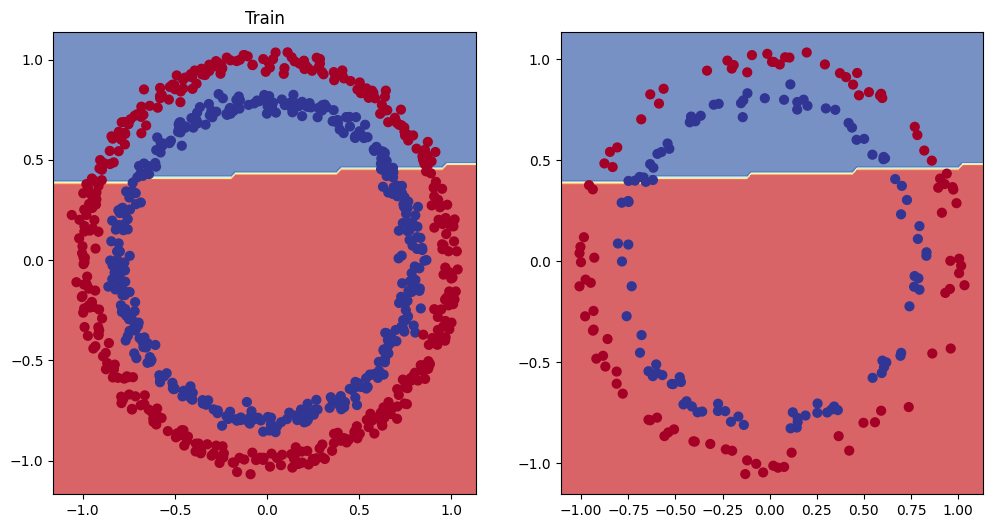

In [100]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) #nrows, ncols, index (which is the position of the current subplot, which is 1-indexed, not 0-indexed)
plt.title("Train")
plot_decision_boundary(model=model_0, X=X_train, y=y_train)
plt.subplot(1, 2, 2)
plot_decision_boundary(model=model_0, X=X_test, y=y_test)

Our model is completely Linear, so it can't really separate with something more complex than a straight line, sadly.

## 5. Improving our model (from a model perspective)

* Add more layers - give the model more chances to learn about patterns in the data
* Add more hidden units - go from 5 hidden units to 10 hidden units. The more parameters, potentially (* you may end up with too many numbers to adjust) better outcome
* Fit for longer
* Changing the activation functions. You can change the end, OR within the model you can add them (i.e. at each layer)
* Change the Learning Rate (if it's too large it may explode, if it's too small it may take too long - see Vanishing and Exploding Gradients as well)
* Change the Loss Function

In [111]:
class ModelReloaded(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(
            in_features = 2,
            out_features = 128
        ), #Multiples of 8 are pretty good
        nn.ReLU(),
        nn.Linear(
            in_features = 128,
            out_features = 256
        ),
        nn.ReLU(),
        nn.Linear(
            in_features=256,
            out_features=128
        ),
        nn.ReLU(),
        nn.Linear(
            in_features=128,
            out_features=1
        )
      )

  def forward(self, x):
    return self.layers.forward(x)


In [112]:
model_1 = ModelReloaded().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    params=model_1.parameters(),
    lr=0.0001
)

In [108]:
y_train.shape

torch.Size([800])

In [113]:
epochs = 1000
torch.manual_seed(42)
torch.cuda.manual_seed(42)

elist = []
losslist = []
testlosslist = []
acclist = []

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  y_logits = model_1.forward(X_train).squeeze() # model_1(X_train)
  y_pred_probs = torch.sigmoid(y_logits) #Into prediction probabilities
  y_preds = torch.round(y_pred_probs)

  # 2. Calculate Loss (& Accuracy!)
  #loss = loss_fn(y_pred_probs, y_train) #If this was just BCELoss this would be good enough, to pass the prediction probabilities.
  loss = loss_fn(
      y_logits, #Our loss function is BCEWithLogitsLoss, which expects logits as input, which is why we pass it y_logits, not y_preds
      y_train
    )

  acc = accuracy_fn(y_true=y_train, y_pred=y_preds)
  acclist.append(acc)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Backpropagation - Loss backward
  loss.backward()

  # 5. Gradient Descent - Update parameters to reduce gradients
  optimizer.step()

  ### Testing
  if epoch % 100 == 0:
    with torch.inference_mode():
      y_test_logits = model_1.forward(X_test).squeeze() # model_1(X_test)
      y_test_pred_probs = torch.sigmoid(y_test_logits)
      y_test_preds = torch.round(y_test_pred_probs).squeeze()

      test_loss = loss_fn(y_test_logits, y_test) #Again, BCEWithLogitsLoss requires the LOGITS
      test_acc = accuracy_fn(y_true=y_test, y_pred=y_test_preds)
      testlosslist.append(test_loss)
    elist.append(epoch)
    losslist.append(loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss} \n Acc: {acc}% | Test Acc: {test_acc}%")
    print("---------------------------------")

Epoch: 0 | Loss: 0.6915155649185181 | Test Loss: 0.691798985004425 
 Acc: 58.875% | Test Acc: 59.5%
---------------------------------
Epoch: 100 | Loss: 0.6000251173973083 | Test Loss: 0.603432834148407 
 Acc: 96.625% | Test Acc: 99.0%
---------------------------------
Epoch: 200 | Loss: 0.25108516216278076 | Test Loss: 0.25222399830818176 
 Acc: 100.0% | Test Acc: 100.0%
---------------------------------
Epoch: 300 | Loss: 0.06965283304452896 | Test Loss: 0.0707014799118042 
 Acc: 100.0% | Test Acc: 100.0%
---------------------------------
Epoch: 400 | Loss: 0.029520275071263313 | Test Loss: 0.03065713681280613 
 Acc: 100.0% | Test Acc: 100.0%
---------------------------------
Epoch: 500 | Loss: 0.01647435873746872 | Test Loss: 0.017696581780910492 
 Acc: 100.0% | Test Acc: 100.0%
---------------------------------
Epoch: 600 | Loss: 0.01059579849243164 | Test Loss: 0.011997341178357601 
 Acc: 100.0% | Test Acc: 100.0%
---------------------------------
Epoch: 700 | Loss: 0.007446488831

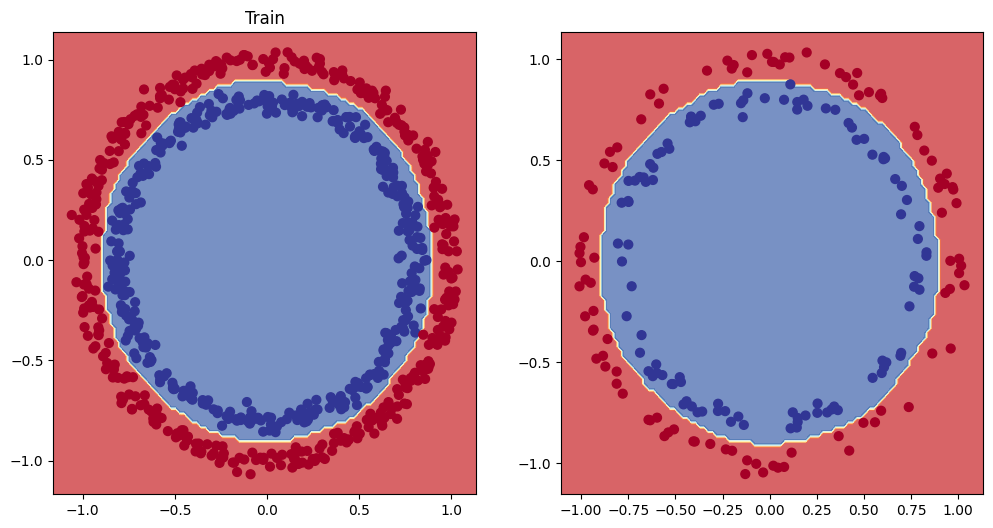

In [115]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) #nrows, ncols, index (which is the position of the current subplot, which is 1-indexed, not 0-indexed)
plt.title("Train")
plot_decision_boundary(model=model_1, X=X_train, y=y_train)
plt.subplot(1, 2, 2)
plot_decision_boundary(model=model_1, X=X_test, y=y_test)

### Improving our model (from the model's perspective) - continued...
We mentioned we can improve our model like so:

* Add more layers
* Add more hidden units
* Fit for longer
* Changing the activation functions. You can change the end, OR within the model you can add them (i.e. at each layer)
* Change the Learning Rate
* Change the Loss Function

These are called "from a model's perspective' because they will deal with the model, and not the data. Since these are all values we engineers/scientists change, they are referred to as **hyperparameters**

- Parameters - Weights and biases. Values the model updates by itself
- Hyperparameters - Values we can change

So let's change some of the hyperparameters of our model.

If we change them all at once, out in the field, you may encounter an issue in which you don't know which change is responsible for whatever different outcome you obtain. You may want to improve the model step by step. That's called **Experiment Tracking** and is very important!

However, for learning purposes, we know this will work , so let's try and improve our model by:
  - Adding more hidden units: 5 -> 10
  - Increase the # of layers: 2 -> 3
  - Increase the number of epochs: 100 -> 1000


In [255]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.relu1 = nn.ReLU() #Adding these makes ALL the difference! Whether ReLU or LeakyReLU
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.relu2 = nn.ReLU()
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    #z = self.layer_1(x)
    #z = self.layer_2(z)
    #z = self.layer_3(z)
    return self.layer_3(self.relu2(self.layer_2(self.relu1(self.layer_1(x))))) #z #This alternative form with z might be slower due to not allowing the computer to optimize this stuff.

In [256]:
modelCV1 = CircleModelV1()
modelCV1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1

In [257]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=modelCV1.parameters(),
                        lr=0.1)

In [258]:
epochs = 1000
torch.manual_seed(42)
torch.cuda.manual_seed(42)

for epoch in range(epochs):
  modelCV1.train()
  y_logits = modelCV1.forward(X_train).squeeze()
  y_pred_probs = torch.sigmoid(y_logits)
  y_preds = torch.round(y_pred_probs)

  loss = loss_fn(y_logits, y_train)

  optimizer.zero_grad()
  loss.backward()
  acc = accuracy_fn(y_true = y_train, y_pred=y_preds)
  optimizer.step()

  if epoch % 100 == 0:
    modelCV1.eval()
    with torch.inference_mode():
      print("Logits:", y_logits[:5].view(-1))           # Should NOT all be ~0
      print("Probs :", torch.sigmoid(y_logits[:5].view(-1)))  # Should vary around 0.5
      y_test_logits = modelCV1.forward(X_test).squeeze()
      y_test_pred_probs = torch.sigmoid(y_test_logits)
      y_test_preds = torch.round(y_test_pred_probs)

      test_acc = accuracy_fn(y_true = y_test, y_pred=y_test_preds)
      test_loss = loss_fn(y_test_logits, y_test)
    print(f"Epoch: {epoch} | A: {acc} | L: {loss} | TA: {test_acc} | TL: {test_loss} ")



Logits: tensor([0.0184, 0.0229, 0.0193, 0.0147, 0.0175], requires_grad=True)
Probs : tensor([0.5046, 0.5057, 0.5048, 0.5037, 0.5044])
Epoch: 0 | A: 49.75 | L: 0.6930632591247559 | TA: 51.0 | TL: 0.6927424669265747 
Logits: tensor([-0.0271, -0.0102, -0.0260, -0.0410, -0.0267], requires_grad=True)
Probs : tensor([0.4932, 0.4975, 0.4935, 0.4898, 0.4933])
Epoch: 100 | A: 52.625 | L: 0.6907008290290833 | TA: 51.0 | TL: 0.6919705867767334 
Logits: tensor([-0.0425, -0.0098, -0.0434, -0.0642, -0.0424], requires_grad=True)
Probs : tensor([0.4894, 0.4975, 0.4891, 0.4840, 0.4894])
Epoch: 200 | A: 53.125 | L: 0.688723087310791 | TA: 51.5 | TL: 0.691231369972229 
Logits: tensor([-0.0588, -0.0053, -0.0634, -0.0934, -0.0599], requires_grad=True)
Probs : tensor([0.4853, 0.4987, 0.4842, 0.4767, 0.4850])
Epoch: 300 | A: 55.125 | L: 0.6859934329986572 | TA: 48.0 | TL: 0.6902545690536499 
Logits: tensor([-0.0662, -0.0057, -0.0810, -0.1329, -0.0806], requires_grad=True)
Probs : tensor([0.4834, 0.4986, 0.47

In [259]:
y_train.dtype, y_logits.dtype
with torch.no_grad():
    y_logits = modelCV1(X_train).view(-1)
    y_probs = torch.sigmoid(y_logits)
    y_pred = (y_probs > 0.5).float()

    print("Predicted probs:", y_probs[:5])
    print("Predicted labels:", y_pred[:5])
    print("True labels:", y_train[:5])

Predicted probs: tensor([0.5695, 0.5784, 0.5841, 0.3577, 0.5329])
Predicted labels: tensor([1., 1., 1., 0., 1.])
True labels: tensor([1., 1., 1., 0., 1.])


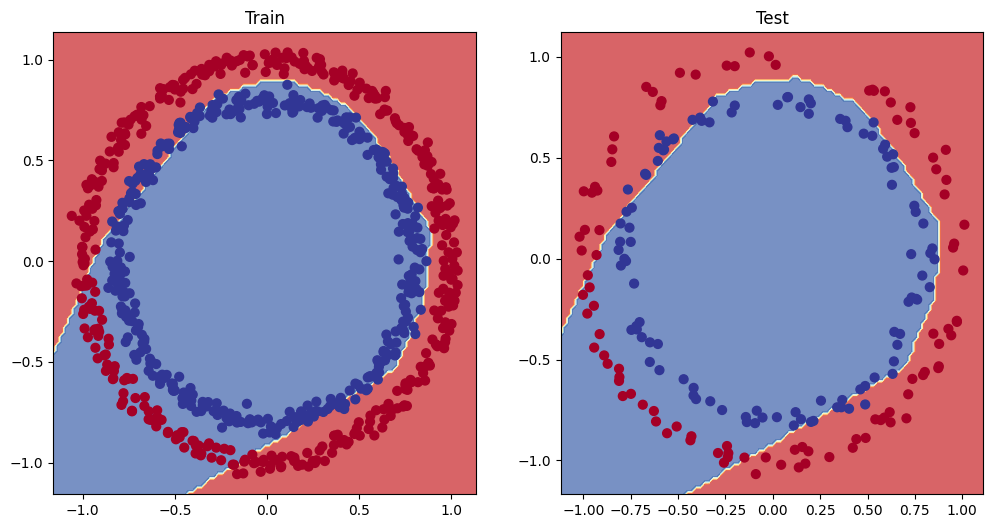

In [261]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) #nrows, ncols, index (which is the position of the current subplot, which is 1-indexed, not 0-indexed)
plt.title("Train")
plot_decision_boundary(model=modelCV1, X=X_train, y=y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model=modelCV1, X=X_test, y=y_test)

In [196]:
with torch.inference_mode():
  y_test_logits = modelCV1.forward(X_test).squeeze() # model_0(X_test)
  y_test_pred_probs = torch.sigmoid(y_test_logits)
  y_test_preds = torch.round(y_test_pred_probs).squeeze()

### Troubleshooting

One way to troubleshoot is to fit a straight line, and see if the model can learn anything at all. Let's make some simpler data that we know that works, and then add more complexity afterwards

In [197]:
weight = 0.7
bias = 0.1
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = X_regression*weight + bias

In [200]:
train_split = int(len(X_regression)*0.8)
X_train, y_train = X_regression[:train_split], y_regression[:train_split]
X_test, y_test = X_regression[train_split:], y_regression[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(80, 80, 20, 20)

In [201]:
def plot_predictions(
    X_train,
    y_train,
    X_test,
    y_test,
    predictions=None
):
  plt.scatter(X_train, y_train, c='b', label='training data')
  plt.scatter(X_test, y_test, c='g', label='test data')
  if predictions is not None:
    plt.scatter(X_test, predictions, c='r', label='predictions')
  plt.legend()

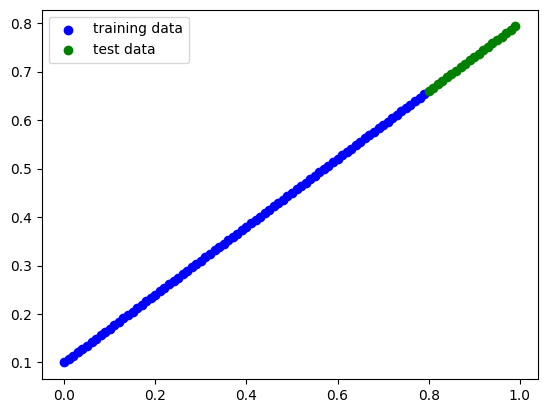

In [218]:
plot_predictions(X_train, y_train, X_test, y_test)

In [219]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=1, out_features=10) #We just changed it from 2 to 1 input features here.
    #self.relu1 = nn.LeakyReLU()
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    #self.relu2 = nn.LeakyReLU()
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    #z = self.layer_1(x)
    #z = self.layer_2(z)
    #z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x))) #z #This alternative form with z might be slower due to not allowing the computer to optimize this stuff.

In [225]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [233]:
modelCV1 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
)
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=modelCV1.parameters(),
                        lr=0.1)

epochs = 1000
torch.manual_seed(42)
torch.cuda.manual_seed(42)

for epoch in range(epochs):
  modelCV1.train()
  y_preds = modelCV1(X_train) # model_1(X_train)

  # 2. Calculate Loss (& Accuracy!)
  #loss = loss_fn(y_pred_probs, y_train) #If this was just BCELoss this would be good enough, to pass the prediction probabilities.
  loss = loss_fn(
      y_preds, #Our loss function is BCEWithLogitsLoss, which expects logits as input, which is why we pass it y_logits, not y_preds
      y_train
    )

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Backpropagation - Loss backward
  loss.backward()

  # 5. Gradient Descent - Update parameters to reduce gradients
  optimizer.step()

  ### Testing
  if epoch % 100 == 0:
    modelCV1.eval()
    with torch.inference_mode():
      y_test_preds = modelCV1(X_test) # model_1(X_test)
      test_loss = loss_fn(y_test_preds, y_test) #Again, BCEWithLogitsLoss requires the LOGITS
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
    print("---------------------------------")



Epoch: 0 | Loss: 0.559858500957489 | Test Loss: 0.3414277732372284
---------------------------------
Epoch: 100 | Loss: 0.05724615976214409 | Test Loss: 0.17025960981845856
---------------------------------
Epoch: 200 | Loss: 0.05749287083745003 | Test Loss: 0.150019571185112
---------------------------------
Epoch: 300 | Loss: 0.05845160037279129 | Test Loss: 0.14985838532447815
---------------------------------
Epoch: 400 | Loss: 0.04713519662618637 | Test Loss: 0.12583765387535095
---------------------------------
Epoch: 500 | Loss: 0.0654468685388565 | Test Loss: 0.12957756221294403
---------------------------------
Epoch: 600 | Loss: 0.06495948135852814 | Test Loss: 0.1302482783794403
---------------------------------
Epoch: 700 | Loss: 0.059344660490751266 | Test Loss: 0.13641014695167542
---------------------------------
Epoch: 800 | Loss: 0.05224599689245224 | Test Loss: 0.12265585362911224
---------------------------------
Epoch: 900 | Loss: 0.057720113545656204 | Test Loss: 0

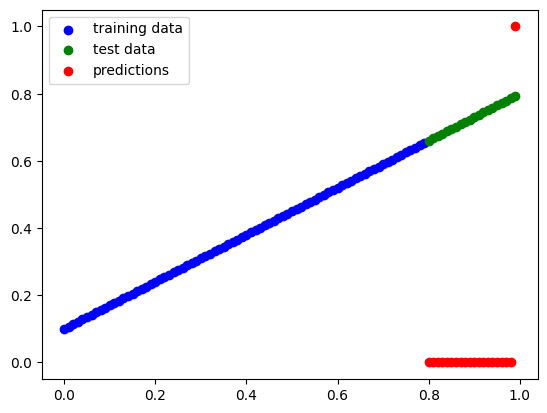

In [211]:
plot_predictions(X_train, y_train, X_test, y_test, predictions=y_test_preds)

### The Missing Piece: Non-Linearity

What patterns could you draw if you were given an infinite amount of straight and non-straight lines?

In Machine Learning an infinite (well, not quite infinite, but) number of linear and non-linear functions?

The part that we were missing to create a good model was non-linearity so that we could recreate non-linear data.

## Recreating non-linear data

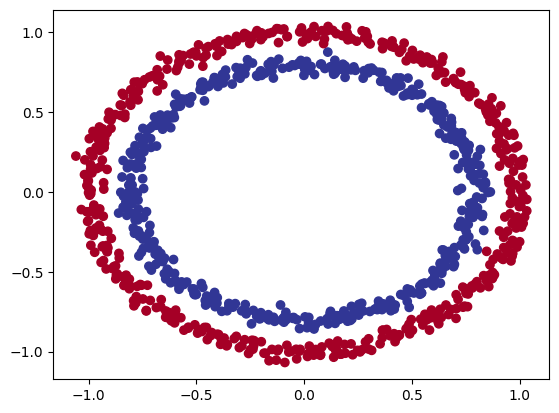

In [265]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(
    n_samples=n_samples,
    noise=0.03,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [268]:
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

TypeError: expected np.ndarray (got Tensor)

In [269]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
len(X_train), len(y_train), len(X_test), len(y_test)

(800, 800, 200, 200)

In [284]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [273]:
import pandas as pd

circles_df = pd.DataFrame(
  {
    "X1": X[:,0],
    "X2": X[:,1],
    "Y": y
  }
)
circles_df

,X1,X2,Y
0,0.754246,0.231481,1.0
1,-0.756159,0.153259,1.0
2,-0.815392,0.173282,1.0
3,-0.393731,0.692883,1.0
4,0.442208,-0.896723,0.0
...,...,...,...
995,0.244054,0.944125,0.0
996,-0.978655,-0.272373,0.0
997,-0.136900,-0.810012,1.0
998,0.670362,-0.767502,0.0


## Building a model with a Non-Linear activation



In [274]:
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x))))) #Just applying relu to Layer 1 and Layer 2.

In [296]:
model_3 = CircleModelV2()
model_3.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1

In [297]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    params=model_3.parameters(),
    lr=0.05
)

In [298]:
epochs = 1000
torch.manual_seed(42)
torch.cuda.manual_seed(42)

for epoch in range(epochs):
  model_3.train()
  y_logits = model_3(X_train).squeeze()

  loss = loss_fn(y_logits, y_train) #BCEWithLogitsLoss means you need the logits
  acc = accuracy_fn(y_true = y_train, y_pred=torch.round(torch.sigmoid(y_logits)))

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  if epoch % 100 == 0:
    model_3.eval()
    with torch.inference_mode():
      y_test_logits = model_3(X_test).squeeze()
      test_loss = loss_fn(y_test_logits, y_test)
    test_acc = accuracy_fn(y_true = y_test, y_pred=torch.round(torch.sigmoid(y_test_logits)))

    print(f"Epoch: {epoch} | Training Loss: {loss:.4f} | Testing Loss: {test_loss:.4f} \n Acc: {acc:.2f} | Test Acc: {test_acc:.2f}")

Epoch: 0 | Training Loss: 0.6930 | Testing Loss: 0.6906 
 Acc: 50.38 | Test Acc: 51.50
Epoch: 100 | Training Loss: 0.0032 | Testing Loss: 0.0063 
 Acc: 100.00 | Test Acc: 100.00
Epoch: 200 | Training Loss: 0.0013 | Testing Loss: 0.0044 
 Acc: 100.00 | Test Acc: 100.00
Epoch: 300 | Training Loss: 0.0007 | Testing Loss: 0.0036 
 Acc: 100.00 | Test Acc: 100.00
Epoch: 400 | Training Loss: 0.0005 | Testing Loss: 0.0033 
 Acc: 100.00 | Test Acc: 100.00
Epoch: 500 | Training Loss: 0.0003 | Testing Loss: 0.0030 
 Acc: 100.00 | Test Acc: 100.00
Epoch: 600 | Training Loss: 0.0002 | Testing Loss: 0.0029 
 Acc: 100.00 | Test Acc: 100.00
Epoch: 700 | Training Loss: 0.0002 | Testing Loss: 0.0028 
 Acc: 100.00 | Test Acc: 100.00
Epoch: 800 | Training Loss: 0.0002 | Testing Loss: 0.0027 
 Acc: 100.00 | Test Acc: 100.00
Epoch: 900 | Training Loss: 0.0001 | Testing Loss: 0.0026 
 Acc: 100.00 | Test Acc: 100.00


Text(0.5, 1.0, 'Test data - Decision Boundary')

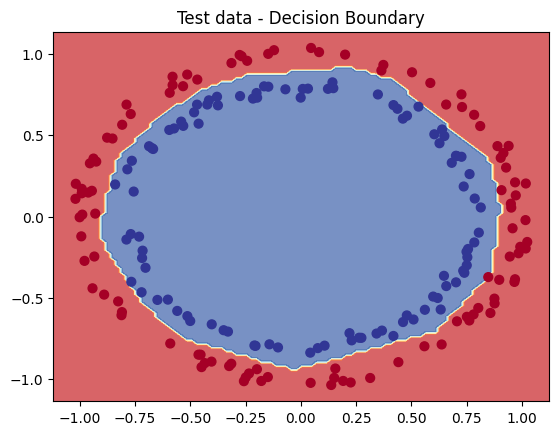

In [299]:
plot_decision_boundary(model=model_3, X=X_test, y=y_test)
plt.title("Test data - Decision Boundary")

## Evaluating a model trained with non-linear activation functions

In [300]:
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 0., 0., 1., 0., 0., 0., 1., 0., 0.]),
 tensor([1., 0., 0., 1., 0., 0., 0., 1., 0., 0.]))

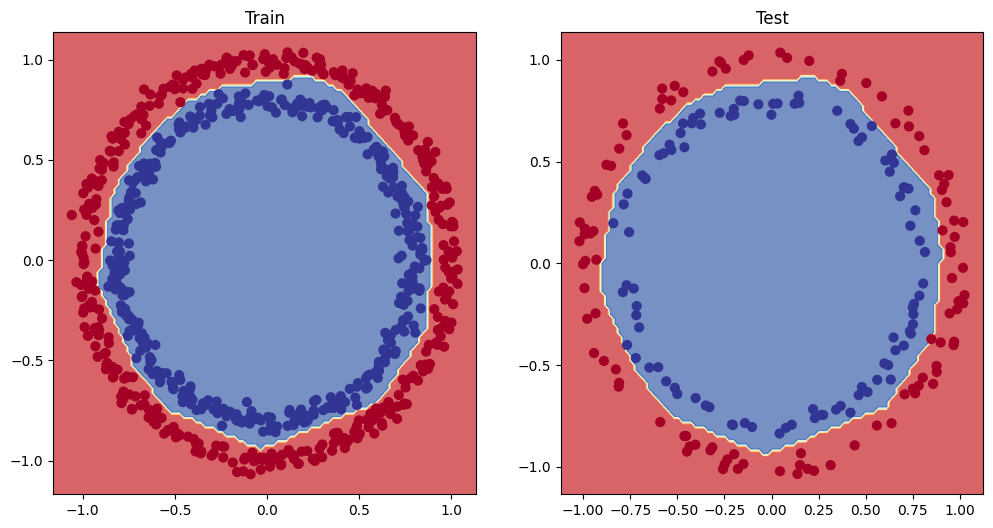

In [301]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model=model_3, X=X_train, y=y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model=model_3, X=X_test, y=y_test)

### Replicating Non-Linear Activation Functions

In Neural Networks, instead of telling the model what to learn, we give it the tools to DISCOVER PATTERNS IN THE DATA. It tries to figure them out on its own.

and these tools are LINEAR & NON-LINEAR FUNCTIONS

In [306]:
A = torch.arange(-10, 10, 1., dtype=torch.float32)
A.dtype

torch.float32

In [307]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

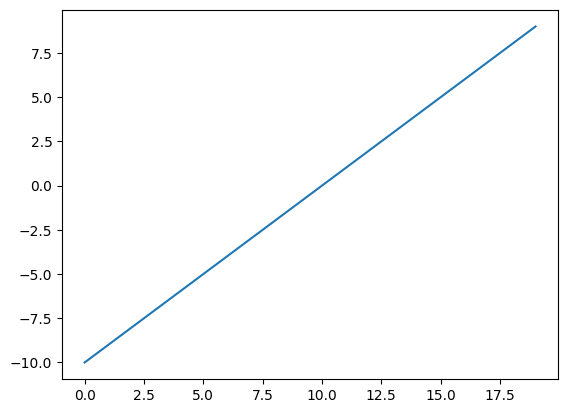

In [308]:
plt.plot(A)

If this is a straight line, how do we apply the ReLU function on it?

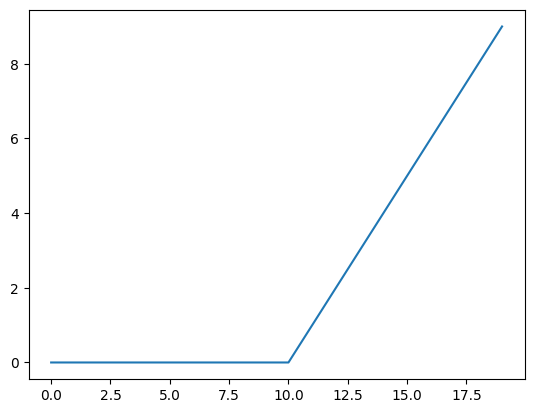

In [312]:
plt.plot(torch.relu(A))

In [313]:
def relu(x : torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.tensor(0), x) #inputs must be tensors

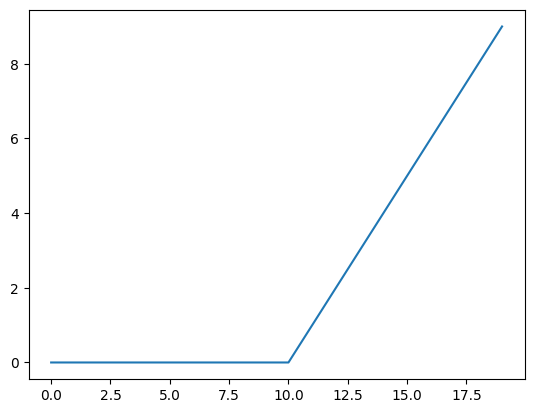

In [314]:
plt.plot(relu(A))

In [320]:
def sigmoid(x : torch.Tensor) -> torch.Tensor:
  return 1/ (1 + torch.exp(-x))

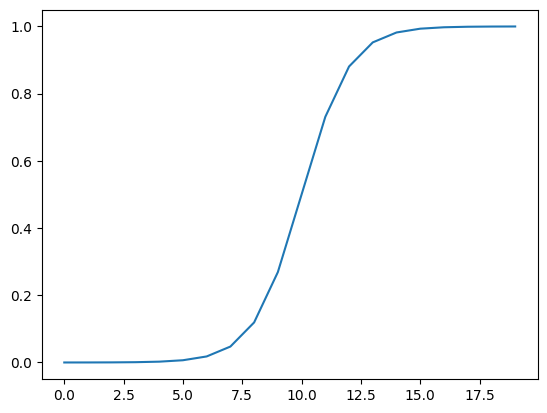

In [321]:
plt.plot(sigmoid(A))

## Building a Multiclass Classifier!

* Binary Classification = One thing or another (Cat / Dog, Spam / Not Spam, Fraud / Not Fraud)
* Multi-class Classification = more than one thing or another (cat / dog / chicken / human)

## Differences
Softmax instead of Sigmoid, and Cross Entropy Loss instead of Binary Cross-Entropy Loss.

In [1]:
# We will begin with creating a Toy Dataset
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

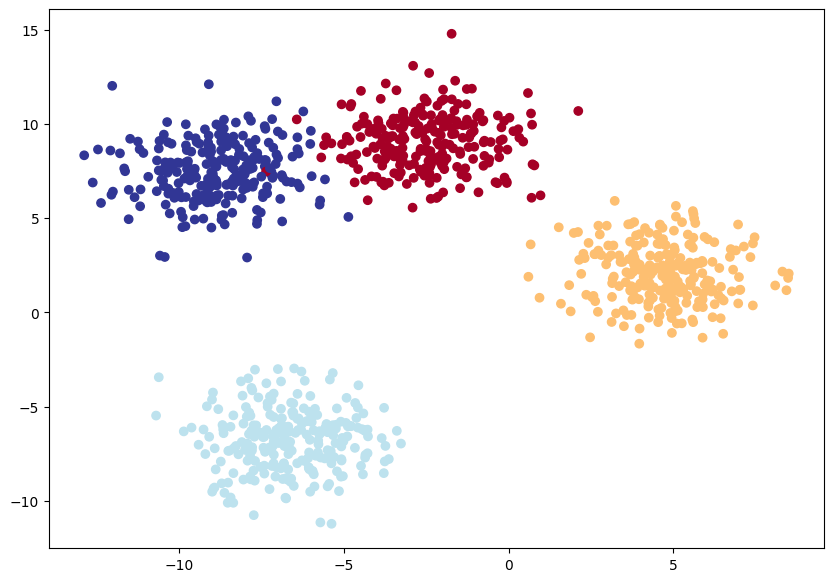

In [5]:
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(
    n_samples=1000,
    n_features=NUM_FEATURES,
    centers=NUM_CLASSES,
    cluster_std=1.5,
    random_state=RANDOM_SEED
)
X_blob, y_blob = torch.from_numpy(X_blob).type(torch.float), torch.from_numpy(y_blob).type(torch.float)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED)

plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

In [6]:
device = 'cuda' if torch.cuda.is_available() else "cpu"

Xb_train, yb_train = Xb_train.to(device), yb_train.to(device)
Xb_test, yb_test = Xb_test.to(device), yb_test.to(device)

In [12]:
from torch import nn

In [20]:
class BlobModel(nn.Module):
  def __init__(self,
               input_features,
               output_features,
               hidden_units=8
    ):
    """ Initializes multi-class classification model

        Args:
          input_features (int): Number of input features to the model
          output_features (int): Number of output features (# of output classes)
          hidden_units(int): Number of hidden units between layers, default=8
    """
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features = input_features, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features),
        #nn.Softmax(dim=0)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

In [7]:
Xb_train.shape, yb_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [8]:
Xb_train[:5], yb_train[:5]

(tensor([[ 5.0405,  3.3076],
         [-2.6249,  9.5260],
         [-8.5240, -9.0402],
         [-6.0262, -4.4375],
         [-3.3397,  7.2175]]),
 tensor([1., 0., 2., 2., 0.]))

In [9]:
torch.unique(yb_train) #How many unique classes

tensor([0., 1., 2., 3.])

In [62]:
model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8
                    ).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

## Create the Loss Function and the Optimizer for the Multi-class Classifier

We could use nn.CrossEntropyLoss.

NOTE: nn.CrossEntropyLoss still expects the Unnormalized Logits

And as an optimizer, torch.optim.SGD() or torch.optim.Adam()

In [63]:
loss_fn = nn.CrossEntropyLoss() #weight argument is for imbalanced dataset, which is not the case for this synthetic dataset.
optimizer = torch.optim.SGD(
    params=model_4.parameters(),
    lr=0.01
)

In [18]:
torch.unique(y_blob, return_counts=True)

(tensor([0., 1., 2., 3.]), tensor([250, 250, 250, 250]))

In [22]:
next(model_4.parameters()).device

device(type='cpu')

In [23]:
Xb_test.device

device(type='cpu')

Our model will output Logits,
we need to transform them into Prediction Probabilities with the Softmax activation function,

And then we will turn PredProbs into Prediction Labels with an argmax.

In [33]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(Xb_test)
y_pred_probs = torch.softmax(y_logits, dim=1)
y_preds = torch.argmax(y_pred_probs, dim=1)
y_logits[:5], y_pred_probs[:5], y_logits.shape, y_pred_probs.shape, y_preds.shape

(tensor([[-0.0161,  0.3881,  1.2026, -0.3174],
         [ 0.7654,  0.1640,  0.6384, -0.6801],
         [-0.5960,  0.3517,  0.6931,  0.1686],
         [-0.2776,  0.3893,  0.8900,  0.1328],
         [ 0.3371,  0.3168,  0.5812, -0.4182]]),
 tensor([[0.1510, 0.2263, 0.5109, 0.1117],
         [0.3753, 0.2057, 0.3306, 0.0884],
         [0.1069, 0.2757, 0.3879, 0.2296],
         [0.1304, 0.2540, 0.4191, 0.1965],
         [0.2684, 0.2630, 0.3426, 0.1261]]),
 torch.Size([200, 4]),
 torch.Size([200, 4]),
 torch.Size([200]))

In [38]:
def softmax(tensor : torch.Tensor, dim: int) -> torch.Tensor:
  return torch.exp(tensor) / torch.sum(torch.exp(tensor),
                                        dim=dim,
                                        keepdim=True) #VERY important to have keepdim so that it's (200, 1) and not (200, ) which can't be broadcast since it doesn't know it's a column tensor

softmax(y_logits, dim=1).shape, torch.sum(y_logits, dim=1, keepdim=True).shape, torch.sum(y_logits, dim=1).shape

(torch.Size([200, 4]), torch.Size([200, 1]), torch.Size([200]))

In [39]:
y_pred_probs[0].sum()

tensor(1.0000)

You can see it sums to 1. That is one of the effects of the Softmax function. It is a division over the sum of each row, after all.

### Convert our model's prediction probabilities to prediction labels

In [41]:
y_preds = torch.argmax(y_pred_probs, dim=1)

y_preds[:5], yb_test[:5]

(tensor([2, 0, 2, 2, 2]), tensor([1., 3., 2., 1., 0.]))

They are all wrong so far, yes, but that's to be expected, since we have not even trained the model.

## 8.5 Training Loop and Testing Loop for a Multi-Class PyTorch Model

In [47]:
# Calculate accuracy - out of 100 examples, what % did our model get right?
def accuracy_fn(
    y_true, y_pred
):
  correct = torch.eq(y_true, y_pred).sum().item() #we want the number solely.
  acc = (correct / len(y_pred)) * 100 #Hey, a classic metric, correctly classified / all elements.
  return acc

In [64]:
epochs = 1000

Xb_train

for epoch in range(epochs):
  model_4.train()
  y_logits = model_4(Xb_train)
  y_pred_probs = torch.softmax(y_logits, dim=1)
  y_preds = torch.argmax(y_pred_probs, dim=1)
  #print(y_logits.dtype, y_pred_probs.dtype, y_preds.dtype)

  loss = loss_fn(y_logits, yb_train.type(torch.long))
  acc = accuracy_fn(y_true=yb_train, y_pred=y_preds)
  optimizer.zero_grad()

  loss.backward()
  optimizer.step()

  if epoch % 100 == 0:
    model_4.eval()
    with torch.inference_mode():
      y_test_logits = model_4(Xb_test)
      y_test_pred_probs = torch.softmax(y_test_logits, dim=1)
      y_test_preds = torch.argmax(y_test_pred_probs, dim=1)
    test_acc = accuracy_fn(y_true=yb_test, y_pred=y_test_preds)
    test_loss = loss_fn(y_test_logits, yb_test.type(torch.long))

    print(f"Epoch: {epoch} | A: {acc:.2f} | L: {loss:.4f} \n             TA: {test_acc:.2f} | TL: {test_loss:.4f}")
    print("--------------------------------")

Epoch: 0 | A: 31.62 | L: 1.4177 
             TA: 43.50 | TL: 1.3660
--------------------------------
Epoch: 100 | A: 98.50 | L: 0.4716 
             TA: 99.00 | TL: 0.4251
--------------------------------
Epoch: 200 | A: 99.38 | L: 0.2681 
             TA: 99.50 | TL: 0.2336
--------------------------------
Epoch: 300 | A: 99.25 | L: 0.1528 
             TA: 99.50 | TL: 0.1313
--------------------------------
Epoch: 400 | A: 99.25 | L: 0.0937 
             TA: 99.50 | TL: 0.0791
--------------------------------
Epoch: 500 | A: 99.25 | L: 0.0668 
             TA: 99.50 | TL: 0.0547
--------------------------------
Epoch: 600 | A: 99.38 | L: 0.0531 
             TA: 99.50 | TL: 0.0420
--------------------------------
Epoch: 700 | A: 99.38 | L: 0.0452 
             TA: 99.50 | TL: 0.0346
--------------------------------
Epoch: 800 | A: 99.38 | L: 0.0400 
             TA: 99.50 | TL: 0.0298
--------------------------------
Epoch: 900 | A: 99.38 | L: 0.0365 
             TA: 99.50 | TL: 0.

Note about that need for a Long Tensor. For some reason PyTorch needs it!

## Making and Evaluating Predictions with a PyTorch multi-class model

In [65]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f: #wb means write binary. We'll create a file and write the content of the request, which is our raw python file
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

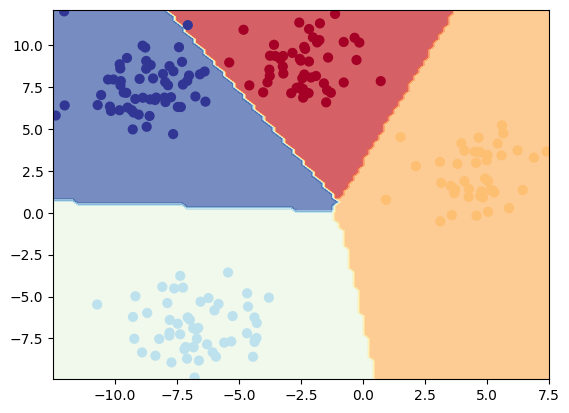

In [66]:
plot_decision_boundary(model_4, X=Xb_test, y=yb_test)

In [67]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(Xb_test)
y_prob_preds = torch.softmax(y_logits, dim=1)
y_preds = torch.argmax(y_prob_preds, dim=1)

In [68]:
y_preds[:10], yb_test[:10]

(tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0]),
 tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0.]))

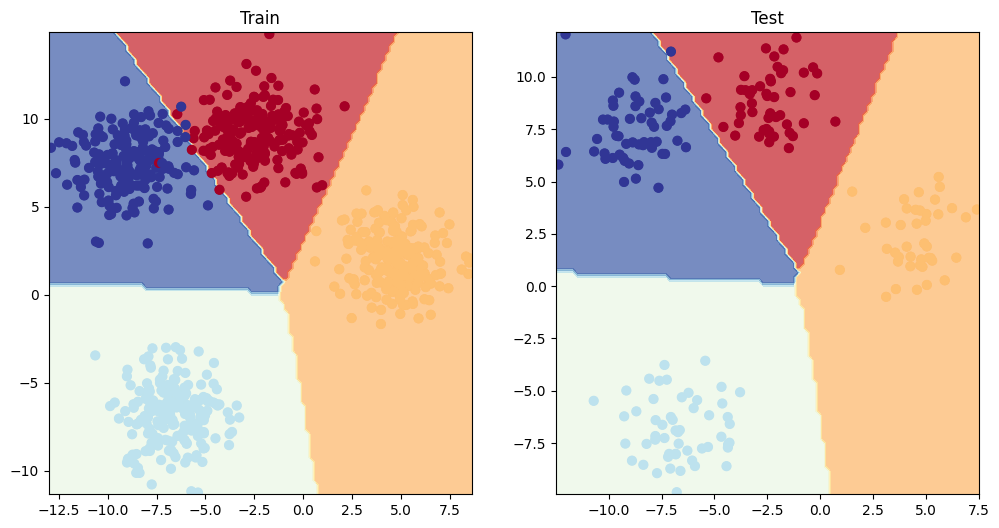

In [69]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plt.scatter(Xb_train[:, 0], Xb_train[:, 1], c=yb_train, cmap=plt.cm.RdYlBu)
plot_decision_boundary(model=model_4, X=Xb_train, y=yb_train)
plt.subplot(1,2,2)
plt.title("Test")
plt.scatter(Xb_test[:,0], Xb_test[:,1], c=yb_test, cmap=plt.cm.RdYlBu)
plot_decision_boundary(model=model_4, X=Xb_test, y=yb_test)

Our data is linearly separable. We can draw straight lines to separate it. That might not always be the case.


But it explains why your model might work even if you comment out the ReLU activations.

## 9. A few more Classification Metrics

* Accuracy - out of 100 samples, how many does our model get right?
* Precision
* Recall
* F1-Score
* Confusion Matrix
* Classification Report

### Accuracy
- (TP + TN) / (TP + TN + FP + FN)
- torchmetrics.Accuracy()
- sklearn.metrics.accuracy_score()
- Use: Default metric for Classification problems. NOT the best for imbalanced classes.

### Precision
- TP / (TP + FP)
- torchmetrics.Precision()
- sklearn.metrics.precision_score()
- Higher precision leads to less False Positives
- See an article for precision vs recall: Towards Data Science - Beyond Accuracy, Precision and Recall
- There is a Precision/Recall trade-off

### Recall
- TP / (TP + FN)
- torchmetrics.Recall()
- sklearn.metrics.recall_score()
- Higher recall leads to less False Negatives

### F1-Score
- 2 * (Precision * Recall) / (Precision + Recall)
- torchmetrics.F1Score()
- sklearn.metrics.f1_score()
- Combination of Precision and Recall.
- Usually a good overall metric for a Classification Model

### Confusion Matrix
- torchmetrics.ConfusionMatrix()
- When comparing Predictions to Truth Labels, to see where the model gets confused
- Can be hard to use with a Large Number of Classes

In [70]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.6/962.6 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 703.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
from torchmetrics import Accuracy

# Setting up the metric!
torchmetric_accuracy = Accuracy().to(device)

torchmetric_accuracy(y_preds, yb_test)